# Grid Imaging and Checking

Inspecting images of gridded data is a valuable way of checking for unusual or undesirable artefacts in the data and several functions are provided for this purpose. The main ones are shown here. Some checks are for delivered grids, and it is also possible to generate and image grids from the located data.

This example uses delivered grids from the Canobie Falcon survey and the Vinton Dome FTG survey.

Note that only grids in the `.ERS` format are able to be checked.

___

Import the required python packages, and set the path to the Canobie geowhizz files.

In [1]:
from pathlib import Path
import galileoQC as qc

In [2]:
data_root = r'./CanobieData/'
canobieHDF_file = Path(r'./CanobieData/Canobie.hdf5')

___

Ideally, the delivered grids from a survey should cover the same areal extent, have the same grid cell size, the same missing data value, the same geographic datum, and so forth. The **`checkErsHeaders`** function compares this information from the first `.ERS` file it encounters in the given directory with all the others, performing a quick and simple check for consistency.

In [3]:
qc.checkErsHeaders(Path(data_root))

Found 8 .ers files ...
in: CanobieData
Comparing ERS files against FSF_GDD_2p67_final.ERS.
[301, 381, 1, -1e+32, 'float32', 0, -1e+32, 'ieee-le', 'EPSG:1168', 'EPSG:7854', 'METERS']
Checking file FSF_GED_2p67_final.ERS
  Checked OK.
Checking file FSF_GEE_2p67_final.ERS
  Checked OK.
Checking file FSF_gD_2P67_final.ERS
  Checked OK.
Checking file FSF_GUV_2p67_final.ERS
  Checked OK.
Checking file FSF_GNN_2p67_final.ERS
  Checked OK.
Checking file FSF_GND_2p67_final.ERS
  Checked OK.
Checking file FSF_GNE_2p67_final.ERS
  Checked OK.


___

A single `.ERS` grid file can be imaged by the **`display_grid`** function. By default, this produces a shaded image.

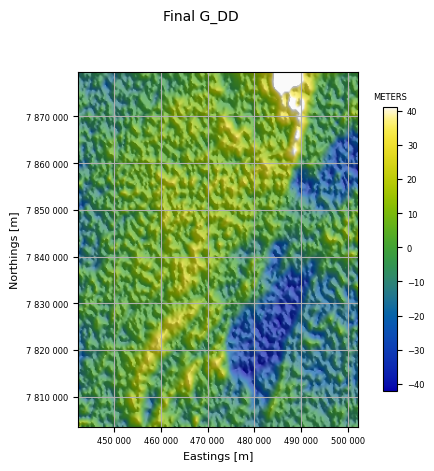

In [4]:
gridfile = Path(data_root + r'FSF_GDD_2p67_final.ERS')
qc.display_grid(gridfile, "Final G_DD", cmap_norm='nonorm', 
    cb_ticks='stats', nSigma=2,
    hs=True, azdeg=45)

___
You can use any Matplotlib colormap, as well as "geosoft" and "parula".

geosoft


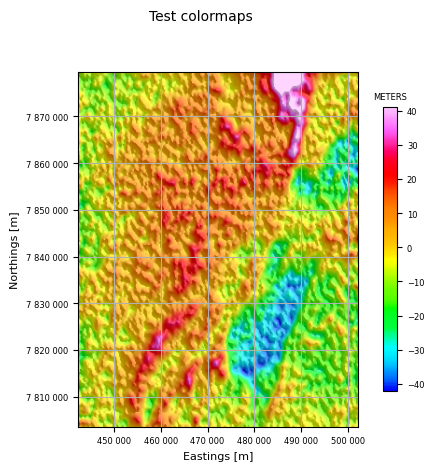

In [5]:
qc.display_grid(Path(data_root + "FSF_GDD_2p67_final.ERS"), 'Test colormaps', colormap="geosoft")

___

The **`imageAllInDir`** function images all `.ers` grids found in the given directory, using the file name as the plot title. The images use the default color look up table and are shaded. This allows a very quick check that all the grids look okay.

Found 8 .ers files ...
in: CanobieData


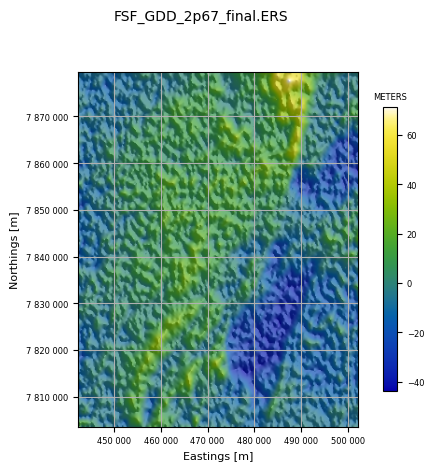

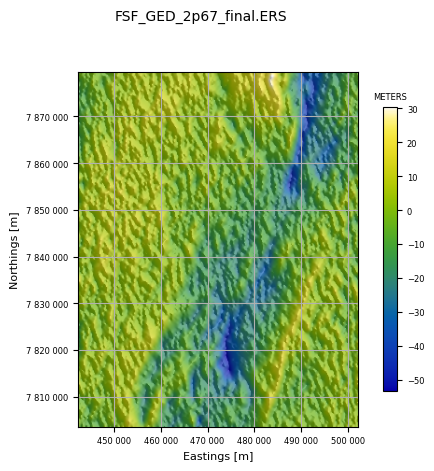

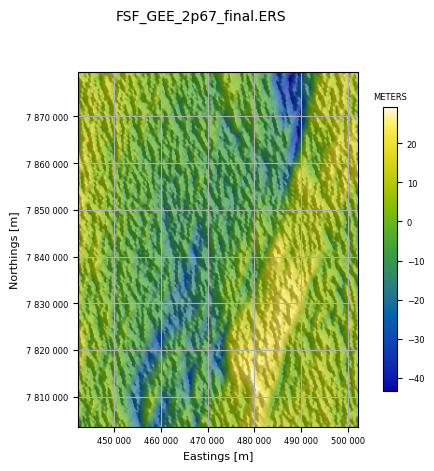

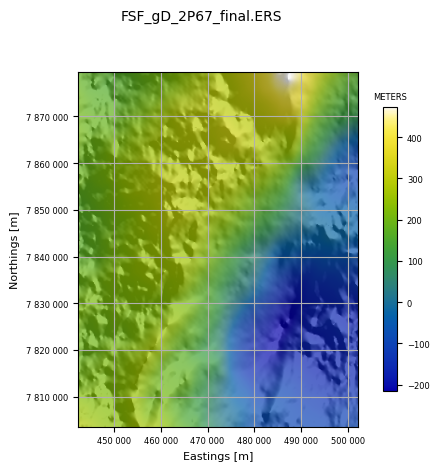

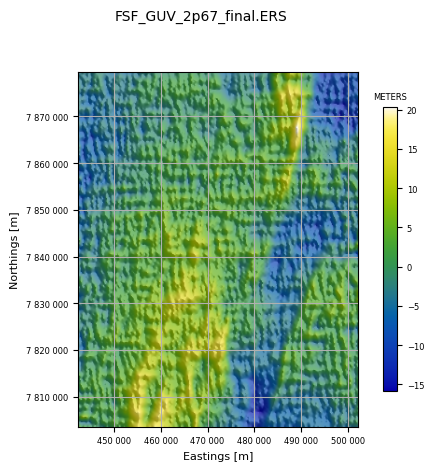

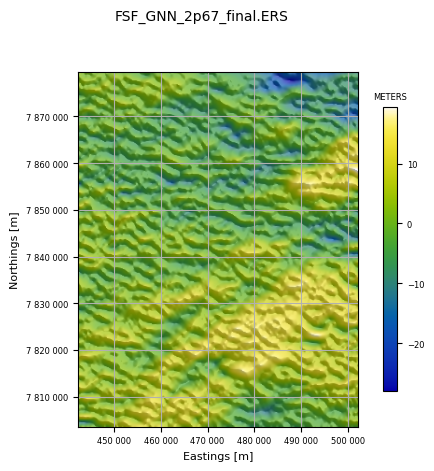

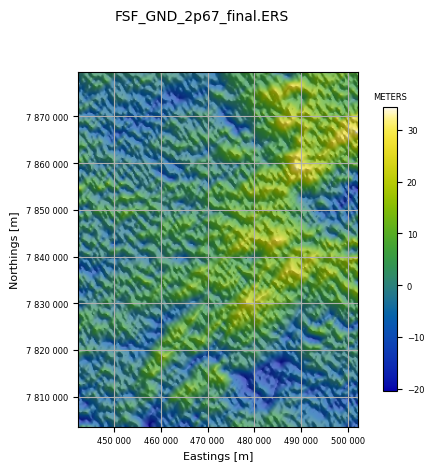

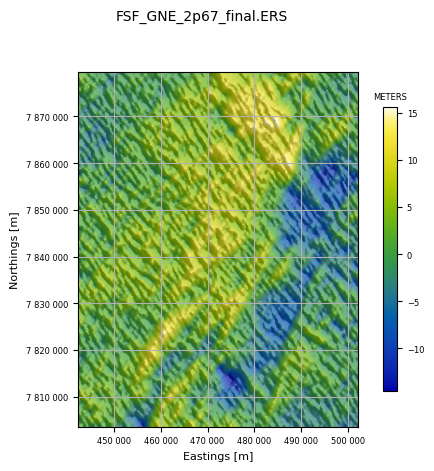

In [6]:
qc.imageAllInDir(Path(data_root))

___

Finally, we can use **`grid_n_image`** to create grids of any channels in the database and image them for viewing.

Errors in the line number, flight number, fiducial, latitude, or any channel at all are possible and can often be easily seen in an image. Accordingly, **`grid_n_image`** is designed to interpolate every named channel to a regular grid and image the grid.

The grid interpolation can be done by the SciPy `griddata` linear method, or by one of the Verde methods: `neighbours`, `bicubic`, or `biharmonic`, or by `minc` (minimum curvature using the implementation in the python pygmi package). Minimum curvature is the usual choice.

Channels (for example, line number, flight number, day of year) might vary between lines but be constant along a line. Others might vary at a constant rate along a line but change dramatically between lines flown on different days or in different directions. And some might change sign depending on line direction (bearing, velocity, Eotvos correction).

Two pre-filters are provided to deal with these situations: a mean-removal filter subtracts the mean of the channel for each line from the data on that line; and a first difference filter returns the difference between successive samples for the gridding algorithm.

The gridded data are imaged on a linear colour stretch with no shading.

The Canobie located data cover a long and thin area somewhat unsuitable for imaging so we will grid and image the Vinton Dome data instead.

First, let us list the available channels. The default is to grid and image all channels in the database. For a demonstration of the key points above, we only need a few.

In [7]:
vintonHDF_file = Path(r'./VintonData/VintonDome.hdf5')

In [8]:
if not vintonHDF_file.exists():
    %run ./Prepare_VintonDomeData.ipynb

In [9]:
qc.reportChannels(vintonHDF_file, verbose=True)

Whizz Version 1.0

28 channels:

  channel              units          description
--------------------------------------------------
  Altitude             m              
  Cross1_raw           eotvos         
  Cross2_raw           eotvos         
  Cross3_raw           eotvos         
  Drape                m              Planned Height
  HHMMSS                              
  Inline1_raw          eotvos         
  Inline2_raw          eotvos         
  Inline3_raw          eotvos         
  Lat                  degree         
  Lon                  degree         
  TC_Txx_100           eotvos         
  TC_Txz_100           eotvos         
  TC_Tyx_100           eotvos         
  TC_Tyy_100           eotvos         
  TC_Tyz_100           eotvos         
  TC_Tzz_100           eotvos         
  Terrain              m              
  Time                 s              
  Txx_slv              eotvos         
  Txz_slv              eotvos         
  Tyx_slv              eotvos    

Here `z_chans` is the list of channels to process. Those in `mr_chans` will have the mean value along each flight-line removed before gridding. Those in `d1_chans` will have the first difference along each flight-line gridded.

The first option is very useful for un-leveled data, and also for channels like heading, or velocity, which are strongly dependent on direction of flight. Here the mean removal filter is applied to `Inline1_raw`. These data are unleveled, and the mean removal acts to level all the data as can be seen by comparing the `Inline1_raw` image with the following on for the `Inline2_raw` channel.

The second option is very useful for data which are expected to vary uniformly with sample number. An example is the `Time` channel in these data. The imaged result shows the result: a completely flat image; any artefacts in the time channel would be very easily seen in this image.

Gridding and imaging Inline1_raw
91 lines; total number of fids in whizz file = 27865.
    Inline1_raw (mr): min = -72.3, max = 47.8, mean = -1.55E-15.

Processing (x, y, z) = (X, Y, MR_Inline1_raw).
 MR_Inline1_raw in eotvos.


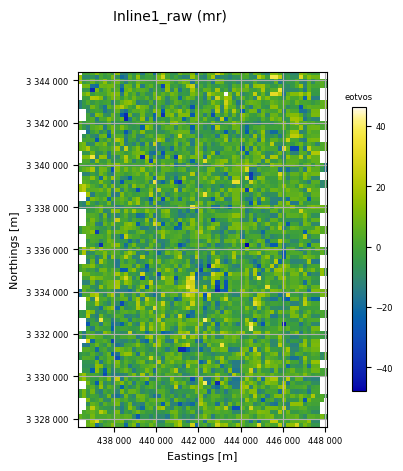

RMS of result = 10.34 eotvos
mean of result = -0.04 eotvos
min of result = -47.88 eotvos
max of result = 46.17 eotvos
Array shape = (85, 60); number of cells = 5100
exscribed rectangle:
  [436298, [3327616],
  [448077, [3327616],
  [448077, [3344418],
  [436298, [3344418]
X cell spacing = 199.647
Y cell spacing = 200.033
number of NaNs = 186

Gridding and imaging Inline2_raw
91 lines; total number of fids in whizz file = 27865.
    Inline2_raw: min = -658, max = -74.8, mean = -418.

Processing (x, y, z) = (X, Y, Inline2_raw).
 Inline2_raw in eotvos.


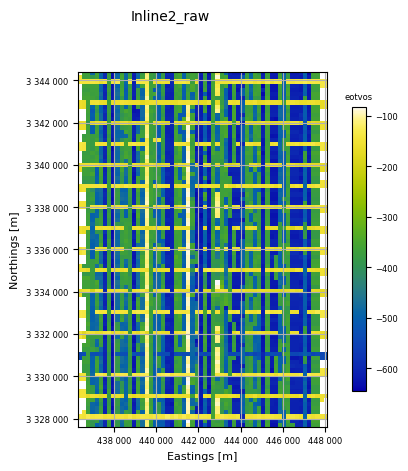

RMS of result = 161.24 eotvos
mean of result = -409.46 eotvos
min of result = -645.05 eotvos
max of result = -83.06 eotvos
Array shape = (85, 60); number of cells = 5100
exscribed rectangle:
  [436298, [3327616],
  [448077, [3327616],
  [448077, [3344418],
  [436298, [3344418]
X cell spacing = 199.647
Y cell spacing = 200.033
number of NaNs = 186

Gridding and imaging Tzz_slv
91 lines; total number of fids in whizz file = 27865.
    Tzz_slv: min = -86.1, max = 79.9, mean = 0.0023.

Processing (x, y, z) = (X, Y, Tzz_slv).
 Tzz_slv in eotvos.


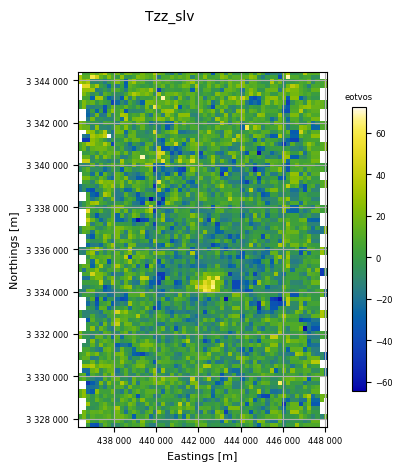

RMS of result = 15.78 eotvos
mean of result = 0.34 eotvos
min of result = -64.42 eotvos
max of result = 72.32 eotvos
Array shape = (85, 60); number of cells = 5100
exscribed rectangle:
  [436298, [3327616],
  [448077, [3327616],
  [448077, [3344418],
  [436298, [3344418]
X cell spacing = 199.647
Y cell spacing = 200.033
number of NaNs = 186

Gridding and imaging Terrain
91 lines; total number of fids in whizz file = 27865.
    Terrain: min = -3.87, max = 24.4, mean = 7.34.

Processing (x, y, z) = (X, Y, Terrain).
 Terrain in m.


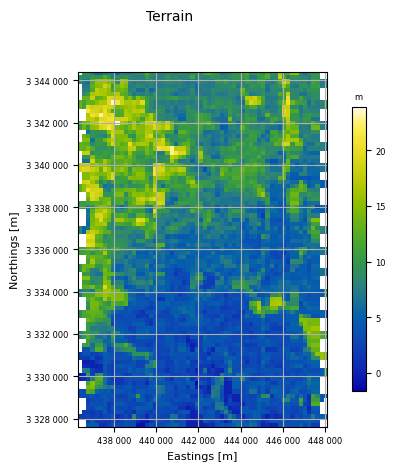

RMS of result = 4.29 m
mean of result = 7.49 m
min of result = -1.65 m
max of result = 23.91 m
Array shape = (85, 60); number of cells = 5100
exscribed rectangle:
  [436298, [3327616],
  [448077, [3327616],
  [448077, [3344418],
  [436298, [3344418]
X cell spacing = 199.647
Y cell spacing = 200.033
number of NaNs = 186

Gridding and imaging Time
91 lines; total number of fids in whizz file = 27865.
    Time (d1): min = 1, max = 1, mean = 1.

Processing (x, y, z) = (X, Y, D1_Time).
 D1_Time in s.


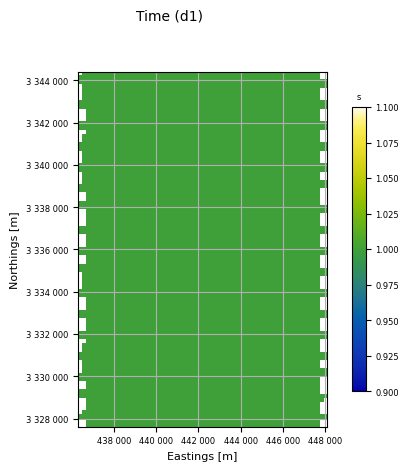

RMS of result = 0.00 s
mean of result = 1.00 s
min of result = 1.00 s
max of result = 1.00 s
Array shape = (85, 60); number of cells = 5100
exscribed rectangle:
  [436298, [3327616],
  [448077, [3327616],
  [448077, [3344418],
  [436298, [3344418]
X cell spacing = 199.647
Y cell spacing = 200.033
number of NaNs = 186

Gridding and imaging Lat
91 lines; total number of fids in whizz file = 27865.
    Lat: min = 30.1, max = 30.2, mean = 30.2.

Processing (x, y, z) = (X, Y, Lat).
 Lat in degree.


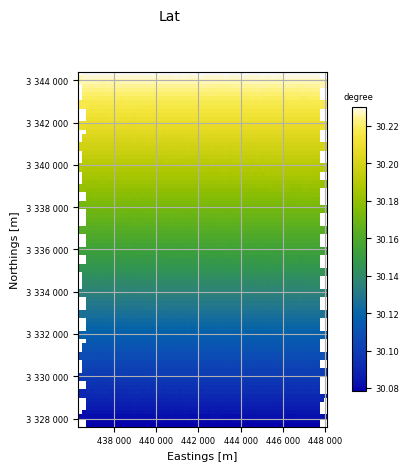

RMS of result = 0.04 degree
mean of result = 30.15 degree
min of result = 30.08 degree
max of result = 30.23 degree
Array shape = (85, 60); number of cells = 5100
exscribed rectangle:
  [436298, [3327616],
  [448077, [3327616],
  [448077, [3344418],
  [436298, [3344418]
X cell spacing = 199.647
Y cell spacing = 200.033
number of NaNs = 186



In [10]:
z_chans = ['Inline1_raw', 'Inline2_raw', 'Tzz_slv', 'Terrain', 'Time', 'Lat']
mr_chans = ['Inline1_raw']
d1_chans = ['Time']
qc.grid_n_image(vintonHDF_file, z_chans, 200.0, mr_chans=mr_chans, d1_chans=d1_chans)

Gridding and imaging Terrain
91 lines; total number of fids in whizz file = 27865.
    Terrain: min = -3.87, max = 24.4, mean = 7.34.

Processing (x, y, z) = (X, Y, Terrain).
 Terrain in m.


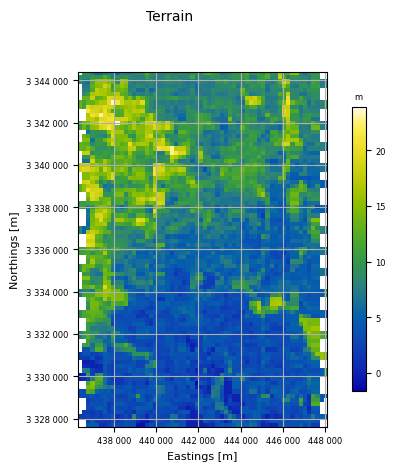

RMS of result = 4.29 m
mean of result = 7.49 m
min of result = -1.65 m
max of result = 23.91 m
Array shape = (85, 60); number of cells = 5100
exscribed rectangle:
  [436298, [3327616],
  [448077, [3327616],
  [448077, [3344418],
  [436298, [3344418]
X cell spacing = 199.647
Y cell spacing = 200.033
number of NaNs = 186



In [11]:
z_chans = ['Terrain']
qc.grid_n_image(vintonHDF_file, z_chans, 200.0)